<img src="./img/img-3.png"><br> 

## 本編の目標

RDKitを用いて力場計算によるコンフォーマー探索を学びます。

1. **RDKitを使った分子のコンフォーマー生成と力場最適化を行う**
2. **生成したコンフォーマーからエネルギーの低い構造を選択する**
3. **選択したコンフォーマーをmol、xyz、gjf形式で保存し、3D可視化する**
4. **UFF・MMFFという2種類の力場の特徴・適用範囲の違いを、実際の分子で確認する**

これら4つの操作について学びます。

## 対象読者・前提知識・動作環境・版とライセンス

- **対象読者**: ARIMデータポータル会員の研究者・技術者。Pythonの基礎文法は理解しているが、RDKit・分子力場・量子化学計算には初めて触れる方を想定しています。統計学・機械学習の予備知識は前提としません。
- **前提知識**: Pythonの基礎文法（変数、for文、関数定義）。
- **用語について**: 本ノートブックが行うのは、力場（UFF・MMFF）を用いた**コンフォーマー探索・構造最適化**です。化学の文脈で「MD」といえば通常は時間発展を伴う**分子動力学（Molecular Dynamics）**を指しますが、本ノートブックの手法はそれとは異なる点に注意してください（力場を使う点は共通ですが、時間発展させず、エネルギー極小構造を直接探索します）。後続の`Psi4-1.ipynb`が行う量子化学計算による構造最適化とも異なる手法です。
- **動作環境**: Google Colab（推奨）またはローカルのJupyter環境。必須ライブラリは`rdkit`・`py3Dmol`です。
- **入力データ**: `data/aspirin.mol`（アスピリンの構造式、C9H8O4。[ChemSpider CSID:2157](https://www.chemspider.com/Chemical-Structure.2157.html)）。本リポジトリ内の他のノートブックと共通のファイルです。
- **版とライセンス**: 本ノートブックはARIMデータポータル会員向けセミナー教材です。ライブラリのバージョンは実行環境によって異なるため、`import rdkit; rdkit.__version__` 等で確認してください（本稿の検証時点ではRDKit 2026.03.4）。

### 教材への接続
google colabにおけるオンラインの場合にこのラインを実行します。（<font color="red">Google colabに接続しない場合には不要</font>）

In [ ]:
!pip install rdkit py3Dmol
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_2_RDKit.git
%cd Advanced_Tutorial_2_RDKit

### ライブラリのインポート
RDkitでコンフォーマーサーチを行うためのpythonのライブラリをimport文でロードします。3D可視化には`py3Dmol`を、mol/xyz/gjfファイルの書き出しには本リポジトリ同梱の`util.py`（`write_xyz_input`・`write_gaussian_input`・`show_3D_from_xyz`）を使います。生成される全てのファイルは`output/`フォルダにまとめて保存します（`OUTPUT_DIR`）。

In [6]:
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole  # Jupyter上でMolオブジェクトを2D構造式としてインライン表示するための設定

from util import write_xyz_input, write_gaussian_input, get_charge_and_multiplicity, show_3D_from_xyz

# 生成物（mol/xyz/gjfファイル）の保存先。ノートブック直下ではなく output/ フォルダにまとめる
# （相対パスのままにしておくと、保存先を示すprint文が output/xxx のように読みやすくなる）
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

import warnings
# RDKitのコンフォーマー生成・力場計算は、立体的に無理のある初期構造に対して
# 多数の情報メッセージ（サニタイズ警告など）を出すことがあるため、
# 教材としての見やすさを優先してここでは抑制しています。
# 実運用でコードを流用する際は、抑制せずに内容を確認することを推奨します。
warnings.filterwarnings('ignore')

## RDKitで扱える分子力場について
<div style="border:1px solid #000; padding:10px;">
量子化学計算を行う前の準備として、分子構造のコンフォーマー探索を行い、安定な構造骨格を得る必要があります。本手法では、RDKitライブラリによる力場計算（UFFまたはMMFF[1]）を用いてコンフォーマーを探索し、最も安定な構造を基に、Gaussian用の入力ファイル（.gjf）、psi4用の.xyzファイル、あるいはmol形式のファイルとして出力します。


[1] Tosco, P., Stiefl, N. & Landrum, G. *Bringing the MMFF force field to the RDKit: implementation and validation.* J Cheminform **6**, 37 (2014). https://doi.org/10.1186/s13321-014-0037-3  

---

### **Universal Force Field (UFF)**  
Universal Force Field（UFF）はコロラド州立大学にて開発された汎用分子力場であり、アクチノイドを含む周期表全元素に対してパラメータが定義されている点に特長があります。元素については横断的な適用性を有するため、広範な分子系に対して構造最適化やコンフォーマー探索を可能とします。一方で、特に金属錯体や無機化合物においては、経験的パラメータの精度や実験データとの整合性に課題があり、定量的な信頼性には限界があります。

### **Merck Molecular Force Field (MMFF)**    
Merck Molecular Force Field（MMFF）は、Merck Research Laboratories によって開発された分子力場であり、従来の MM3 力場の設計思想を継承・発展させたものです。MMFF は有機分子全般に対して高い再現性と精度を発揮するように設計されていることに特長があります。一方で、下記の「MMFFのコンフォーマー生成における留意点 」にあるような、分子構造によっては計算に困難を伴うことがあります。

### MMFFのコンフォーマー生成における留意点  
以下に示す構造的特徴を有する分子は、MMFFに基づく構造最適化およびコンフォーマー生成において困難を伴うことがあります。

- **長鎖アルキル基**  
  十分な柔軟性を持つ長鎖アルキル基は、多数の回転異性体を生み出しうるため、コンフォーマー空間が極めて広大となり、探索アルゴリズムの収束に時間を要することがあります。
  
- **複雑な縮合環系**  
  多環芳香族や縮合複素環を有する分子は、構造の剛直性が高く、コンフォーマー空間が限られるため、探索効率が低下する傾向があります。

- **嵩高い置換基の存在**  
  イソプロピル基やトリフルオロメチル基といった立体的にかさばる置換基は、コンフォーマー生成アルゴリズムにおいて不自然な衝突やコンフォーマーの収束失敗を引き起こす要因となります。

- **電荷を有する官能基**  
  正電荷を有する四級アンモニウム（[N+]）、負電荷を有するボロネートアニオン（[B-]）などの存在は、静電ポテンシャル場の形成に大きく影響し、構造最適化の収束を妨げる可能性があります。

- **ボロン (B) を含む構造**  
  ボロンは多様な配位数と結合様式を示し、MMFFとの整合性が乏しい場合があります。特に、ボロンに窒素や芳香環が直接結合している構造では、立体的拘束が大きく、初期構造生成に失敗することがあります。

- **ボロン-窒素 (B–N) 結合環**  
  一部の分子においては、B–N結合を含む芳香族様の環構造が確認されており、電子的特性や結合の特殊性が力場のパラメータ化と整合しない可能性があります。

上記のうち「ボロンを含む構造」については、次の節で実際のデータを使って確認します。

### 参考：MMFFの限界を実例で確認する

上の「留意点」で述べた内容を、実際に手を動かして確認してみましょう。`data/smiles_10.csv` に収録されている10分子のうち、6番目（ID=6）はホウ素（B）と窒素（N）を含むNHC（N-heterocyclic carbene）ボラン様の構造です。

MMFF94の元となったHalgrenの原論文はC・H・N・O・F・Si・P・S・Cl・Br・Iなど有機分子でよく使われる元素を中心にパラメータ化されており、ホウ素は対象に含まれていません。そのため、ホウ素を含む分子ではMMFFのパラメータが用意できず、RDKitの`AllChem.MMFFGetMoleculeProperties()`は`None`を返します（例外を送出せず`None`を返す点に注意が必要です。`None`のまま`AllChem.MMFFGetMoleculeForceField()`に渡すと後続の`Minimize()`呼び出しでエラーになります）。

RDKitには、力場を実際に組み立てる前に対応可否を確認できる`AllChem.UFFHasAllMoleculeParams(mol)`・`AllChem.MMFFHasAllMoleculeParams(mol)`という関数が用意されています。次のコードではこの2つの関数を使って、UFFとMMFFそれぞれがこの分子に対応できるかを確認します。

In [9]:
import pandas as pd

# data/smiles_10.csv からホウ素を含む分子（ID=6）を1件だけ読み込む
df_ref = pd.read_csv('data/smiles_10.csv')
row = df_ref[df_ref['ID'] == 6].iloc[0]
ref_smiles = row['SMILES']
print(f"対象分子のSMILES: {ref_smiles}")

ref_mol = Chem.MolFromSmiles(ref_smiles)
ref_mol = Chem.AddHs(ref_mol)
print(f"原子数（水素込み）: {ref_mol.GetNumAtoms()}")

print(f"UFFHasAllMoleculeParams:  {AllChem.UFFHasAllMoleculeParams(ref_mol)}")
print(f"MMFFHasAllMoleculeParams: {AllChem.MMFFHasAllMoleculeParams(ref_mol)}")

対象分子のSMILES: CC(C)C(C=CC=C1C(C)C)=C1N2C=CN(C3=C(C(C)C)C=CC=C3C(C)C)B2C4=CC=CC=C4
原子数（水素込み）: 76
UFFHasAllMoleculeParams:  True
MMFFHasAllMoleculeParams: False


In [10]:
# 3次元構造を1つ生成し、UFFとMMFFそれぞれで最適化を試みる
ref_cid = AllChem.EmbedMolecule(ref_mol, randomSeed=42)

# UFF: 周期表全元素に対応しているため問題なく計算できる
ff_uff = AllChem.UFFGetMoleculeForceField(ref_mol, confId=ref_cid)
ff_uff.Minimize()
print(f"UFFでの最適化: 成功（エネルギー = {ff_uff.CalcEnergy():.2f} kcal/mol）")

# MMFF: ホウ素のパラメータが無いため MMFFGetMoleculeProperties() が None を返す
mmff_props = AllChem.MMFFGetMoleculeProperties(ref_mol, mmffVariant='MMFF94')
if mmff_props is None:
    print("MMFFでの最適化: 失敗（MMFFGetMoleculeProperties()がNoneを返した = ホウ素のパラメータが定義されていない）")
else:
    ff_mmff = AllChem.MMFFGetMoleculeForceField(ref_mol, mmff_props, confId=ref_cid)
    ff_mmff.Minimize()
    print(f"MMFFでの最適化: 成功（エネルギー = {ff_mmff.CalcEnergy():.2f} kcal/mol）")

UFFでの最適化: 成功（エネルギー = 105.35 kcal/mol）
MMFFでの最適化: 失敗（MMFFGetMoleculeProperties()がNoneを返した = ホウ素のパラメータが定義されていない）


**結果の考察**: `MMFFHasAllMoleculeParams()`が`False`を返し、実際に`MMFFGetMoleculeProperties()`も`None`を返しました。これは理論通り、MMFF94がホウ素原子のパラメータを持たないために起きています。一方UFFは周期表全元素に対応しているため、同じ分子でも問題なく最適化できています。この後の本編ではアスピリン（C, H, Oのみで構成）を扱うため、この問題には遭遇しませんが、皆さん自身の分子でMMFFを使う際は、事前に`MMFFHasAllMoleculeParams()`で確認する習慣をつけると、原因不明のエラーを避けられます。

## 1.ファイルの読み込み
解熱鎮痛剤のアセチルサリチル酸（アスピリン）を例にして、MOL形式ファイルからデータを読み込む方法を紹介します。MOLファイルは、[data]という名前のフォルダに保存されていることを想定しています。

In [13]:
#fileの相対パスを定義
file ='data/aspirin.mol'

# molファイル読み込み
mol = Chem.MolFromMolFile(file, removeHs=False)

分子`mol`に対して、水素原子を付加します。この操作は、コンフォーマー探索の計算処理に向けた重要な前処理で、精度の高い分子モデリングを行うための基本的なステップとなります。

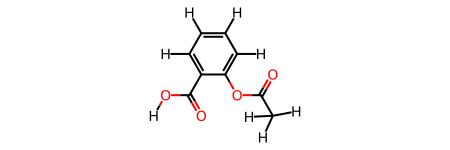

In [15]:
mol = Chem.AddHs(mol, addCoords=True)
mol

【解説】**`Chem.AddHs()`** メソッド

既存の分子オブジェクトに対して、水素原子（Hydrogen atoms）を付加する操作を行うものです。水素付加後の分子オブジェクトは、オリジナルとは異なる新たなインスタンスであるため、元の分子オブジェクトを直接変更するわけではない点に留意が必要です。

```python
mol = Chem.AddHs(mol, addCoords=True)
```

- `addCoords=True` ：　もとの分子が三次元座標（原子位置情報）を有している場合には、追加される水素原子にも座標が補完されます。すなわち、適切な立体配置が維持される形で水素が付加されます。
- `addCoords=False`（デフォルト）：水素原子に座標は与えられず、単に結合情報のみが付加されます。

## 2.コンフォーマー生成
対象分子に対して複数の三次元コンフォーマー（3D conformers）を生成する工程を実施します。

In [18]:
# 初期設定
confs = 1000        # コンフォーマーの発生数
rms = 0.5           # 類似した構造を排除する枝刈りレベル
pickup = 1          # コンフォーマーの選択数（上位pickup個を採用する）
forcefield = "uff"  # "uff" または "mmff"

In [19]:
#コンフォーマー探索
cids = AllChem.EmbedMultipleConfs(
    mol,
    numConfs=confs,
    pruneRmsThresh=rms,
    randomSeed=1234
)

if len(cids) == 0:
    # 立体的に無理のある分子では、EmbedMultipleConfsが1つもコンフォーマーを
    # 生成できず空のリストを返すことがある（演習問題1で他の分子を試す際に遭遇しうる）。
    # 後続セルで原因不明のエラーになる前に、ここで分かりやすく止める。
    raise RuntimeError(
        "コンフォーマーを1つも生成できませんでした（EmbedMultipleConfsが空のリストを返しました）。"
        "分子の立体構造に無理がある可能性があります。"
        "EmbedMultipleConfs(..., useRandomCoords=True) を試す、または別の分子で確認してください。"
    )

print(f"生成されたコンフォーマー数: {len(cids)}")

生成されたコンフォーマー数: 2


---

【解説】AllChem.EmbedMultipleConfs()メソッドについて

`rdkit.Chem.AllChem.EmbedMultipleConfs()` は、指定した分子（`Mol`オブジェクト）に対して、**複数の三次元コンフォーマー**（3D conformers）を生成するための関数です。分子モデリング、立体配座探索、エネルギー最適化など、下流の化学情報学プロセスにおいて必須となる初期構造群を提供します。


#### 1. 主な引数

| 引数 | 説明 |
|:---|:---|
| `mol` | コンフォーマーを生成する対象の`Mol`オブジェクト。 |
| `numConfs` | 生成を試みるコンフォーマーの最大数（デフォルト：10）。 |
| `pruneRmsThresh` | 枝刈り（pruning）閾値。生成されたコンフォーマー同士のRMSD（Root Mean Square Deviation）がこの値未満であれば、冗長と見なして破棄される（デフォルト：-1.0、すなわち枝刈りを行わない）。 |
| `randomSeed` | 乱数生成器のシード。固定することで結果の再現性を確保できる。 |
| `useExpTorsionAnglePrefs` | 既知のトーション角情報（例えば結晶構造から得られたもの）を利用するか（デフォルト：`True`）。 |
| `useBasicKnowledge` | 一般的な化学構造知識（例えば、sp²炭素は平面構造を取るべき等）を利用するか（デフォルト：`True`）。 |


#### 2. 戻り値

関数は、**生成されたコンフォーマーのID番号（`confId`）のリスト** を返却する。各IDは、`Mol`オブジェクト内の個々のコンフォーマーにアクセスする際に用いられる。例えば、生成されたコンフォーマーに対して個別にエネルギー最適化やファイル出力を行う際、`confId`を指定することが求められる。

**補足**: 上のセルの出力を見ると、`numConfs=1000`を指定したにもかかわらず、実際に得られたコンフォーマー数はごく少数です。これは`pruneRmsThresh=0.5`により、既に見つかっている構造とRMSDが0.5Å未満の「似た構造」が枝刈りされるためです。アスピリンは回転可能な結合が少なく取りうる立体配座の種類が本質的に少ないため、多くの試行が同じような構造に収束し、結果として枝刈り後に残るコンフォーマー数が少なくなっています。分子がもっと柔軟であれば、この数はより多くなります。

---

## 3.実行（コンフォーマー探索）
生成された複数の三次元コンフォーマーそれぞれに対して、力場計算を用いてエネルギー最適化を行い、さらに最適化後のエネルギーを算出します。ff.Minimize() を呼び出すことで、対象コンフォーマーのエネルギー最小化計算（構造緩和）が実行され、力場に基づき、結合長、結合角、二面角、非結合性相互作用などが考慮されながら、構造は局所的なエネルギー極小点へと緩和されます。最適化後に得られたエネルギー値と対応するコンフォーマーIDは、タプル (cid, energy) の形式でリスト energies に格納されます。このリストは、たとえば最も安定なコンフォーマーを選択するなど、後続の処理に利用されます。

In [22]:
# forcefield の指定を検証する（前節の参考デモの通り、MMFFは全ての分子に対応できるわけではない）
if forcefield.lower() not in ("uff", "mmff"):
    raise ValueError(f"未対応の forcefield です: {forcefield!r}（'uff' または 'mmff' を指定してください）")

if forcefield.lower() == "mmff" and not AllChem.MMFFHasAllMoleculeParams(mol):
    raise ValueError(
        "MMFFはこの分子の全原子に対応するパラメータを持っていません。"
        "forcefield='uff' に切り替えるか、別の分子を使用してください。"
    )

# コンフォーマーごとのエネルギー最適化
energies = []

for cid in cids:
    if forcefield.lower() == "uff":
        ff = AllChem.UFFGetMoleculeForceField(mol, confId=cid)
    elif forcefield.lower() == "mmff":
        props = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant='MMFF94')
        ff = AllChem.MMFFGetMoleculeForceField(mol, props, confId=cid)

    ff.Minimize()
    energy = ff.CalcEnergy()
    energies.append((cid, energy))

【解説】

冒頭の2つの`if`文は、前節「参考：MMFFの限界を実例で確認する」で見たとおり、`forcefield='mmff'`かつMMFFが対応していない分子を渡すと、`AllChem.MMFFGetMoleculeProperties()`が`None`を返し、その後の`ff.Minimize()`で分かりにくいエラーになってしまうことを防ぐためのガードです。問題があれば、ループに入る前の時点で分かりやすいエラーメッセージを出して止めます。

#### forcefield が `'uff'` のとき

```python
ff = AllChem.UFFGetMoleculeForceField(mol, confId=cid)
ff.Minimize()
energies.append((cid, ff.CalcEnergy()))
```

- UFF（Universal Force Field）を用いて最適化。
- `Minimize()` でエネルギー最小化。
- `CalcEnergy()` で最小化後のエネルギーを取得。
- `(コンフォーマーID, エネルギー)` のタプルとしてリストに追加。

#### forcefield が `'mmff'` のとき

```python
props = AllChem.MMFFGetMoleculeProperties(mol)
```

- MMFF（Merck Molecular Force Field）ではまず `props`（分子の性質情報）を取得する必要があります。

```python
ff = AllChem.MMFFGetMoleculeForceField(mol, props, confId=cid)
ff.Minimize()
energies.append((cid, ff.CalcEnergy()))
```

- `props` を使ってMMFF用の力場を生成。
- `Minimize()` → `CalcEnergy()` → 追加、は UFF と同様。
- タプルの順序は `(コンフォーマーID, エネルギー)` で、`energies`リストの並び順もこの順序で統一されています。

## 3-2. UFFとMMFFの比較（参考）
本編で使うのはどちらか一方の力場（`forcefield`変数で指定した方）ですが、せっかく2種類の力場を紹介したので、同じ分子・同じコンフォーマー集合に対してUFFとMMFFの両方でエネルギー最適化を行い、結果を比較してみましょう。アスピリンはC・H・Oのみで構成されるため、`MMFFHasAllMoleculeParams()`で確認した通りMMFFでも問題なく計算できます。

なお、UFFとMMFFはエネルギーの基準（ゼロ点の取り方）が異なる別々の力場であるため、**異なる分子間や異なる力場間で絶対値そのものを直接比較することはできません**。ここで比較するのは、あくまで「同じ力場の中でどのコンフォーマーが相対的に安定か」という順位（ランキング）が、力場を変えても一致するかどうかです。

In [25]:
# 同じ cids に対して、UFFとMMFFの両方でエネルギーを計算する
uff_energies = {}
for cid in cids:
    ff = AllChem.UFFGetMoleculeForceField(mol, confId=cid)
    ff.Minimize()
    uff_energies[cid] = ff.CalcEnergy()

mmff_energies = {}
if AllChem.MMFFHasAllMoleculeParams(mol):
    mmff_props = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant='MMFF94')
    for cid in cids:
        ff = AllChem.MMFFGetMoleculeForceField(mol, mmff_props, confId=cid)
        ff.Minimize()
        mmff_energies[cid] = ff.CalcEnergy()

# 比較表を作成（各力場について、そのコンフォーマー集合内での最小値を0とした相対エネルギーも併記）
uff_min = min(uff_energies.values())
mmff_min = min(mmff_energies.values()) if mmff_energies else float("nan")

comparison_df = pd.DataFrame({
    "conformer_id": list(cids),
    "uff_energy_kcal_mol": [uff_energies[cid] for cid in cids],
    "uff_relative_kcal_mol": [uff_energies[cid] - uff_min for cid in cids],
    "mmff_energy_kcal_mol": [mmff_energies.get(cid, float("nan")) for cid in cids],
    "mmff_relative_kcal_mol": [mmff_energies.get(cid, float("nan")) - mmff_min for cid in cids],
})
comparison_df["uff_rank"] = comparison_df["uff_relative_kcal_mol"].rank().astype(int)
comparison_df["mmff_rank"] = comparison_df["mmff_relative_kcal_mol"].rank().astype(int)
comparison_df

,conformer_id,uff_energy_kcal_mol,uff_relative_kcal_mol,mmff_energy_kcal_mol,mmff_relative_kcal_mol,uff_rank,mmff_rank
0,0,23.880718,0.068544,20.833145,1.923376,2,2
1,1,23.812174,0.000000,18.909769,0.000000,1,1


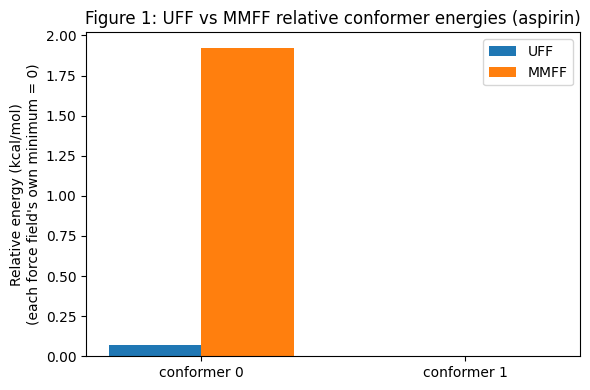

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(comparison_df))
width = 0.35
ax.bar([i - width / 2 for i in x], comparison_df["uff_relative_kcal_mol"], width, label="UFF")
ax.bar([i + width / 2 for i in x], comparison_df["mmff_relative_kcal_mol"], width, label="MMFF")
ax.set_xticks(list(x))
ax.set_xticklabels([f"conformer {cid}" for cid in comparison_df["conformer_id"]])
ax.set_ylabel("Relative energy (kcal/mol)\n(each force field's own minimum = 0)")
ax.set_title("Figure 1: UFF vs MMFF relative conformer energies (aspirin)")
ax.legend()
fig.tight_layout()
plt.show()

**考察（図1）**: 枝刈り後に残ったコンフォーマー数がもともと少ないため（前節参照）、ここでの比較サンプル数はごく小さいですが、UFFとMMFFのどちらでも同じコンフォーマーが最も安定（相対エネルギー0）と判定されており、順位が一致していることが分かります。これは偶然ではなく、多くの有機小分子ではUFFとMMFFのどちらを使っても「どの立体配座が相対的に安定か」という定性的な結論は一致しやすいことの一例です（ただし絶対的なエネルギー値やエネルギー差の大きさは力場によって異なります）。分子がもっと複雑・柔軟になると、この一致は必ずしも保証されない点には注意してください。

## 4.最安定構造のファイル出力
その後、エネルギーが低い順に上位`pickup`個の構造について.mol, .xyz, .gjf ファイルとして保存を行います（`pickup=1`の場合は最安定構造のみ）。ファイルはノートブック直下ではなく`output/`フォルダ（`OUTPUT_DIR`）にまとめて保存します。.gjfファイルの1行目付近に書き込む電荷・スピン多重度は、`util.get_charge_and_multiplicity()`で分子から自動計算します（詳細は`util.py`のdocstringを参照してください。閉殻の有機分子であれば通常「電荷0・多重度1」になります）。

In [29]:
# ソート用の関数を定義
def get_energy(item):
    return item[1]

# エネルギーでソートして最も低いものから並べる
energies.sort(key=get_energy)

In [30]:
energies

[(1, 23.812173737469404), (0, 23.880717994122325)]

In [31]:
# エネルギーが低い順に上位 pickup 個のコンフォーマーIDを取得
top_cids = [cid for cid, energy in energies[:pickup]]
print(f"保存対象のコンフォーマーID（エネルギーが低い順）: {top_cids}")

# 電荷・スピン多重度を分子から自動計算（.gjfファイルの2行目に使用）
charge, multiplicity = get_charge_and_multiplicity(mol)
print(f"電荷: {charge}, スピン多重度: {multiplicity}")

保存対象のコンフォーマーID（エネルギーが低い順）: [1]
電荷: 0, スピン多重度: 1


In [32]:
# 保存（上位 pickup 個。pickup=1 の場合は optimized_conformer_1.* のみ生成される）
# ファイルはすべて OUTPUT_DIR（output/フォルダ）に保存する
saved_base_names = []

for rank, cid in enumerate(top_cids, start=1):
    base_name = f"optimized_conformer_{rank}"
    saved_base_names.append(base_name)

    # molファイル保存
    molfile = str(OUTPUT_DIR / (base_name + ".mol"))
    Chem.MolToMolFile(mol, molfile, confId=cid)
    print(f"コンフォーマー {cid}（{rank}位）を {molfile} に保存しました。")

コンフォーマー 1（1位）を output/optimized_conformer_1.mol に保存しました。


In [33]:
# 選ばれたコンフォーマーを .xyz, .gjf 形式でも保存する（util.py のヘルパー関数を使用）
for rank, cid, base_name in zip(range(1, len(top_cids) + 1), top_cids, saved_base_names):
    xyzfile = str(OUTPUT_DIR / (base_name + ".xyz"))
    write_xyz_input(mol, cid, xyzfile, comment=f"{base_name} (rank={rank})")
    print(f"コンフォーマー {cid}（{rank}位）を {xyzfile} に保存しました。")

    gjffile = str(OUTPUT_DIR / (base_name + ".gjf"))
    write_gaussian_input(
        mol, cid, gjffile,
        method="b3lyp", basis="6-31g(d)", title=base_name,
        charge=charge, multiplicity=multiplicity,
        route_extra="opt freq",
    )
    print(f"コンフォーマー {cid}（{rank}位）を {gjffile} に保存しました。")

コンフォーマー 1（1位）を output/optimized_conformer_1.xyz に保存しました。
コンフォーマー 1（1位）を output/optimized_conformer_1.gjf に保存しました。


## 5.最安定構造の可視化
`util.show_3D_from_xyz()` を使ってpy3Dmolから、`output/`フォルダに保存したコンフォーマーを可視化します（`pickup=1`の既定設定では最安定構造1つのみが表示されます）。

In [35]:
# 保存した構造を順番に表示する（output/フォルダから読み込む）
for rank, base_name in enumerate(saved_base_names, start=1):
    xyz_path = str(OUTPUT_DIR / f"{base_name}.xyz")
    print(f"{rank}位: {xyz_path}")
    show_3D_from_xyz(xyz_path)

1位: output/optimized_conformer_1.xyz


## まとめ

本ノートブックでは、RDKitを用いて次の作業を行いました。

- MOL形式ファイルから分子を読み込み、`AllChem.EmbedMultipleConfs()`で複数の3Dコンフォーマーを生成した
- UFF・MMFFいずれかの力場でコンフォーマーごとにエネルギー最小化を行い、最も安定な構造を選んだ
- 選択したコンフォーマーをmol・xyz・gjf形式で保存し、py3Dmolで3D可視化した
- UFFとMMFFという2種類の力場について、周期表上の対応範囲の違い（UFFは全元素対応、MMFFは有機分子中心でホウ素等は非対応）を、実際にホウ素を含む分子で確認した
- 同じ分子について両方の力場でエネルギーを計算し、コンフォーマーの安定性の順位が一致することを確認した

## 本ノートブックで扱っていないこと（今後の課題）

- **分子動力学（MD）**: 冒頭で述べた通り、本ノートブックは静的な構造最適化（コンフォーマー探索）のみを扱っています。温度・時間発展を伴う分子動力学シミュレーションは扱っていません。
- **量子化学計算**: 力場計算はあくまで量子化学計算（Psi4やGaussianなど）の前段階として、良い初期構造を得るためのものです。より高精度なエネルギー・構造を得るには、後続の`Psi4-1.ipynb`のように量子化学計算を行う必要があります。
- **複数分子の一括処理**: 本ノートブックは1分子（アスピリン）を対象としていますが、`data/smiles_10.csv`のような複数分子を一括処理する場合は、本編で追加した`MMFFHasAllMoleculeParams()`によるチェックや、分子ごとの失敗を記録する仕組み（例外を捕捉してログに残す等）を組み込むことを推奨します。
- **力場パラメータの妥当性の検証**: UFF・MMFFいずれも経験的パラメータに基づく近似手法であり、特に金属錯体や特殊な官能基を含む分子では実験値との整合性を別途確認する必要があります。

## 演習問題

1. `data/smiles_10.csv`に含まれる他の分子（ID=6以外）について、`AllChem.MMFFHasAllMoleculeParams()`で対応可否を確認し、UFF・MMFFそれぞれでコンフォーマー生成・エネルギー最小化を行ってみましょう。
2. 初期設定セルの`pruneRmsThresh`（`rms`変数）の値を0.5から0.1や1.0に変えて`EmbedMultipleConfs()`を再実行し、生成されるコンフォーマー数がどう変化するか確認してみましょう。
3. `pickup`の値を1から3に変更し、上位3つのコンフォーマーがそれぞれmol・xyz・gjfファイルとして保存されることを確認してみましょう。
4. `util.get_charge_and_multiplicity()`のdocstringを読み、なぜスピン多重度の推定が近似（不対電子数+1）に留まるのか、閉殻分子とラジカル分子を例に説明してみましょう。
5. アスピリン以外の、自分の興味のある分子のSMILES文字列やMOLファイルを用意し、本ノートブックと同じ手順でコンフォーマー探索・構造最適化を行ってみましょう。